## Empirical Parameters
Here I make some figures to justify the use of the empirical parameters in the two layer model.

In [1]:
import copy
import sys
import os
import re
import inspect
import scipy.optimize

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.surface_flux_taylor_2layer import get_p_eff, get_temp_from_sphum_sat, get_sensible_heat, get_latent_heat
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic, get_fit_coef_complex
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

from jobs.thesis_season.column.utils import get_flux

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff3

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
# exp_dir = f'thesis_season/column/depth=20/tau_sweep/'
exp_dir = f'tau_sweep/aquaplanet/depth=1/'
exp_name = 'k=1'

lat_target = 40
ds_base = utils.load_ds(exp_name, exp_dir, lat_target=lat_target,
                        first_month_file=2 if 'column' in exp_dir else 25, verbose=True, n_lat=0)
ds = utils.process_ds(ds_base)

Computing column temp, sphum, and rh: 100%|██████████| 3/3 [00:18<00:00,  6.07s/it]


In [3]:
def get_error(var, var_approx, time=ds.time, annual_harmonic=True):
    var_fourier, var_amp, _ = utils.get_fourier_fit_xr(time, var, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)
    var_amp = var_amp.sel(harmonic=1)
    if annual_harmonic:
        var_approx_fourier = utils.get_fourier_fit_xr(time, var_approx, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)[0]
        return np.abs(var_fourier-var_approx_fourier).mean(dim='time') / var_amp * 100
    else:
        # Get error relative to annual harmonic amplitude
        return np.abs(var-var_approx).mean(dim='time') / var_amp * 100

### Surface Fluxes
Here I record the error in various approximations in the surface fluxes involved in both the surface and atmospheric energy budget.


In [4]:
def update_args(args_base, params, arg_names):
    args_use = args_base.copy()
    for key in arg_names:
        if key in params:
            args_use[key] = params[key]
    return args_use

In [5]:
var = ds.flux_lhe+ds.flux_t+ds.lwup_sfc-ds.lwdn_sfc
energy_budget_terms = {'surf_flux': {'simulated': var-var.mean(dim='time')}}
energy_budget_error = {'surf_flux': {}}

In [6]:
args_names_atmos = list(inspect.signature(utils.get_approx_flux_atmos).parameters.keys())
args_base_atmos = {key: ds[key] for key in args_names_atmos if key in ds}
args_base_atmos['sw_abs'] = 0     # get rid of SW component of RHS of fluxes, as not interested in approximation of this term

# Get error with just surface temperature
lambda_s = utils.get_fit_complex_xr(ds.temp_surf, energy_budget_terms['surf_flux']['simulated'])[0]
key = 'lambda_s'
energy_budget_terms['surf_flux'][key] = utils.apply_linear_zero_mean_xr(ds.temp_surf, lambda_s)
energy_budget_error['surf_flux'][key] = get_error(energy_budget_terms['surf_flux']['simulated'], energy_budget_terms['surf_flux'][key])

param_order = ['lambda_const', 'lambda_a', 'coef_phase_a']
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = utils.get_empirical_params(ds, include_params=include_params, empirical_lambda_const=key=='lambda_const')
    args_use = update_args(args_base_atmos, feedback_params_use, args_names_atmos)
    energy_budget_terms['surf_flux'][key] = utils.get_approx_flux_atmos(**args_use)
    energy_budget_error['surf_flux'][key] = get_error(energy_budget_terms['surf_flux']['simulated'], energy_budget_terms['surf_flux'][key])



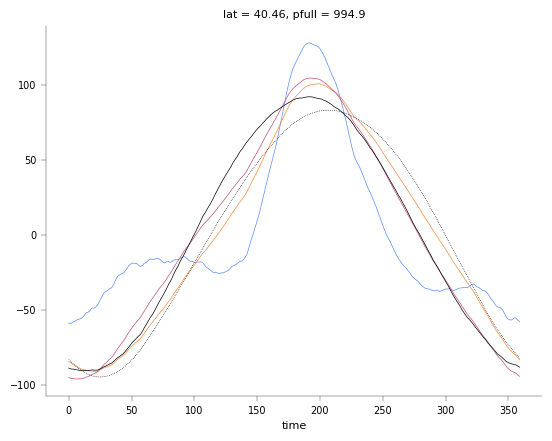

In [7]:
energy_budget_terms['surf_flux']['lambda_const'].plot()
energy_budget_terms['surf_flux']['lambda_a'].plot()
energy_budget_terms['surf_flux']['coef_phase_a'].plot()
energy_budget_terms['surf_flux']['lambda_s'].plot(color='k', linestyle=':')
energy_budget_terms['surf_flux']['simulated'].plot(color='k')

### OLR + Advection
For simplicity, I neglect the surface contribution to OLR and assume it all arises from the atmosphere.

In [8]:
key2 = 'olr_advect'
var = ds.adv_atmos - ds.olr
energy_budget_terms[key2] =  {'simulated': var-var.mean(dim='time')}
energy_budget_error[key2] = {}

# Neglect any surface OLR for simplicity
if 'column' in exp_dir:
    param_order = ['B', 'coef_phase_olr']
else:
    param_order = ['B', 'lambda_adv', 'coef_phase_adv', 'coef_phase_olr']
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = utils.get_empirical_params(ds, include_params=include_params, include_olr_surf_cont=False)
    args_use = update_args(args_base_atmos, feedback_params_use, args_names_atmos)
    energy_budget_terms[key2][key] = utils.get_approx_flux_atmos(**args_use) + \
                                     utils.get_approx_adv_atmos(ds.temp_atm, feedback_params_use['lambda_adv'], feedback_params_use['coef_phase_adv'])
    energy_budget_error[key2][key] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2][key])

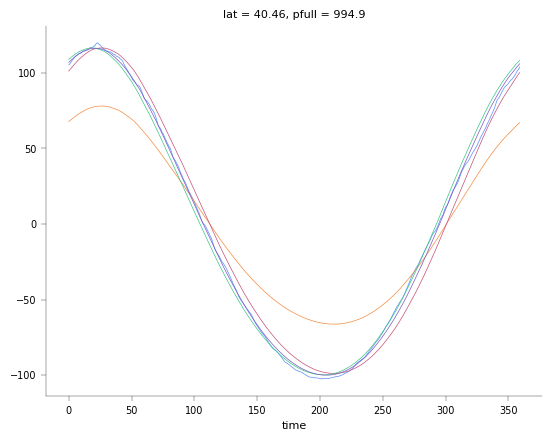

In [9]:
for key in energy_budget_terms[key2]:
    energy_budget_terms[key2][key].plot()

## MSE Tendency
See that phase here actually makes approximtion worse. Maybe because not in annual harmonic?? I used the annual harmonic to obtain the phase factors.

We see a notable error here, because we are approximating $dq_{col}/dt$ as $\mu dT_a/dt$, but really it should be $\mu (T_a-\overline{T}_a)dT_a/dt$ because of nonlinear clausius clapeyron effect. This effect causes $dq_{col}/dt$ to have significant second harmonic hence the error seen is very notable for the all harmonic error, but is still present for annual harmonic, as in the approximation we are taking the annual harmonic of $\mu dT_a/dt$ not $\mu (T_a-\overline{T}_a)dT_a/dt$, which are slightly different.

In [10]:
key2 = 'mse_tend'
var = ds.mse_tend_atmos
energy_budget_terms[key2] =  {'simulated': var-var.mean(dim='time')}
energy_budget_error[key2] = {}

# energy_budget_terms[key2]['none'] = utils.get_approx_mse_tend(ds.temp_atm, 1,
#                                                            0, 0,
#                                                            ds.p_integ_calc.mean(dim='time'), ds.time)
# energy_budget_error[key2]['none'] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2]['none'])

param_order = ['coef_amp_col', 'mu', 'coef_phase_col']
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = utils.get_empirical_params(ds, include_params=include_params)
    energy_budget_terms[key2][key] = utils.get_approx_mse_tend(ds.temp_atm, feedback_params_use['coef_amp_col'],
                                                               feedback_params_use['coef_phase_col'], feedback_params_use['mu'],
                                                               ds.p_integ_calc.mean(dim='time'), ds.time)
    energy_budget_error[key2][key] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2][key])

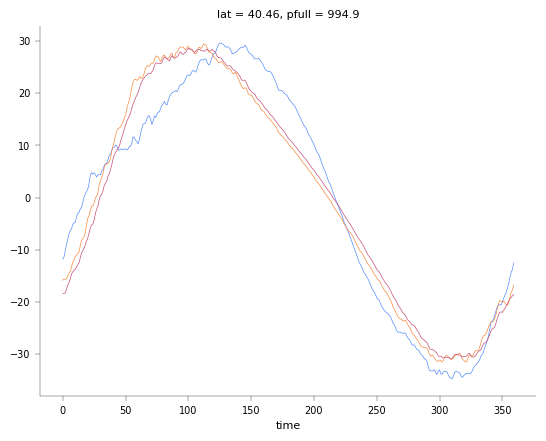

In [11]:
energy_budget_terms[key2]['simulated'].plot()
# # energy_budget_terms[key2]['none'].plot()
# energy_budget_terms[key2]['coef_amp_col'].plot()
energy_budget_terms[key2]['mu'].plot()
energy_budget_terms[key2]['coef_phase_col'].plot()
# utils.get_fourier_fit_xr(ds.time, energy_budget_terms[key2]['simulated'], n_harmonics=1,  pad_coefs_phase=True)[0].plot()
# utils.get_fourier_fit_xr(ds.time, energy_budget_terms[key2]['coef_phase_col'], n_harmonics=1,  pad_coefs_phase=True)[0].plot()
# energy_budget_terms[key2]['coef_amp_col'].plot()
# energy_budget_terms[key2]['coef_phase_col'].plot()

### Paper figure
Plot the error as more parameters added to the approximation. These errors are in terms of the annual harmonic rather than the all harmonics.

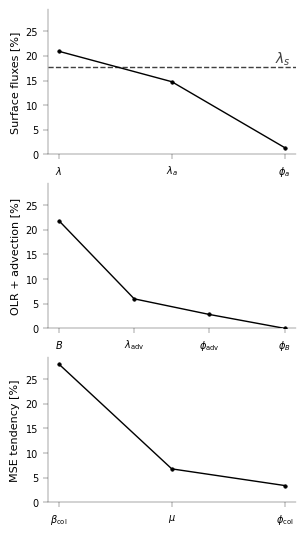

In [12]:
labels_use = {'surf_flux': 'Surface fluxes [%]', 'olr_advect': 'OLR + advection [%]', 'mse_tend': 'MSE tendency [%]'}
energy_budget_labels = {'lambda_s': r'$\lambda_s$', 'lambda_const': r'$\lambda$', 'lambda_a': r'$\lambda_a$',
                        'coef_phase_a': r'$\phi_a$', 'B': '$B$', 'lambda_lw': r'$\lambda_{\text{LW}}$',
                        'lambda_adv': r'$\lambda_{\text{adv}}$', 'coef_phase_adv': r'$\phi_{\text{adv}}$',
                        'coef_phase_olr': r'$\phi_{B}$', 'coef_amp_col': r'$\beta_{\text{col}}$',
                        'mu': r"$\mu$", 'coef_phase_col': r'$\phi_{\text{col}}$'}
fig, ax = plt.subplots(len(energy_budget_error), 1, sharey=True)
fig_resize(fig, utils.width['one_col'], 1.5)

for iax, component in zip(ax, energy_budget_error):
    approximations = energy_budget_error[component]

    # lambda_s is a surface-flux reference, not part of the x-axis sequence
    lambda_s_error = None
    xlabels = []
    errors = []

    for approximation, error in approximations.items():
        if component == 'surf_flux' and approximation == 'lambda_s':
            lambda_s_error = error
        else:
            xlabels.append(energy_budget_labels[approximation])
            errors.append(error)

    # Approximation errors represented as categorical points
    if errors:
        x = np.arange(len(xlabels))

        iax.plot(
            x,
            errors,
            marker='o',
            color='k',
            markeredgecolor='k',
            markeredgewidth=0.5,
            zorder=3,
        )

        iax.set_xticks(x)
        iax.set_xticklabels(xlabels)

    else:
        # Preserve a visible axis when this panel contains only lambda_s
        iax.set_xticks([])
        iax.set_xlim(0, 1)

    # Surface-flux reference error
    if lambda_s_error is not None:
        iax.axhline(
            lambda_s_error,
            color='0.25',
            ls='--',
            zorder=1,
        )

        iax.text(
            0.98,
            lambda_s_error,
            r'$\lambda_s$',
            transform=iax.get_yaxis_transform(),
            ha='right',
            va='bottom',
            color='0.25',
        )

    iax.set_ylabel(labels_use[component])
    # iax.grid(axis='y', color='0.85', lw=0.6)
update_linewidth(fig)
ax[0].set_ylim(0, ax[0].get_ylim()[1])
plt.show()

In [12]:
# TODO: take final feeback params including everything and incrementally plot the lambda_eff, C_eff, phase and gain as each parameter is added with arrows in between. Maybe markers for phase parameters are different to lambda params.